In [1]:
import warnings

import pooch

# don't have pooch output messages about downloading or untarring
logger = pooch.get_logger()
logger.setLevel("WARNING")

# don't need to show warning about setting up optimizer and scheduler
warnings.filterwarnings(
    "ignore",
    message="You will need to call setup",
    category=UserWarning,
)

:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`feather2023.ipynb`**!

Run it in your browser: **{binder}`feather2023.ipynb`**!

:::

(feather2023)=
# Reproducing ResNet50 Image Metamers from Feather et al., 2023

:::{warning}
This notebook requires the optional dependency `torchvision`, which can be installed with `pip`.
:::

In this notebook, we will reproduce some of the model metamers presented in {cite:alp}`Feather2023-model-metam`: metamers for layers 2, 3, and 4 of the standard ImageNet-trained ResNet50, as shown in Figure 2e of that paper.

:::{admonition} Using Deep Nets with plenoptic
:class: warning

We strongly recommended reading [](deep_nets) before this notebook, to better understand the use of {class}`~plenoptic.models.DeepNetFeatures`.

:::

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import plenoptic as po

# this notebook uses torchvision, which is an optional dependency. if this import fails,
# install torchvision in your plenoptic environment and restart the notebook kernel.
try:
    import torchvision
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

# set seed for reproducibility
po.set_seed(1)

## Prepare model and image for synthesis

In the following block, we create a separate {class}`~plenoptic.models.DeepNetFeatures` model for each of layers 2, 3, and 4. We then prepare the image. Finally, we ensure that the model and image have the proper device and dtype, and remove the gradient from all model parameters. To learn more about any of these steps and why we take them, read [](deep_nets).

In [3]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
deepnet = torchvision.models.resnet50(weights=weights)
deepnet.eval()
transform = weights.transforms()
norm = torchvision.transforms.Normalize(transform.mean, transform.std)

layers = ["layer2", "layer3", "layer4"]
models = []
for target_layer in layers:
    models.append(po.models.DeepNetFeatures(deepnet, target_layer, norm))

img = po.data.macaque()
# here we downsample the original image by a factor of 4 and then lop off the bottom.
# that way, when we take the central 224 pixels in the following block, we end up with a
# decent image.
img = po.process.blur_downsample(img, 2)[..., :-59, :]
img = po.process.center_crop(img, transform.crop_size[0])
# po.plot.imshow(img, as_rgb=True);

img = img.to(DEVICE).to(torch.float64)
for model in models:
    model.to(DEVICE).to(torch.float64)
    po.remove_grad(model)

## Initialize and load Metamer objects

:::{admonition} This notebook retrieves cached synthesis results
:class: warning dropdown

The example metamers shown in this notebook takes about 15 minutes to synthesize on a GPU. Thus, instead of performing synthesis in this notebook, we have cached the result of it online and download them for investigation.

:::

Now that our models and images are prepared, we can initialize our {class}`~plenoptic.Metamer` objects. We'll then load in the cached output so we can examine the resulting metamers.

In [4]:
metamers = []
for model, target_layer in zip(models, layers):
    met = po.Metamer(img, model)
    met.load(
        po.data.fetch_data(f"ResNet50-{target_layer}_macaque_metamer.pt"),
        map_location=DEVICE,
        tensor_equality_atol=1e-6,
    )
    metamers.append(met)

  0%|                                     | 1.02k/12.9M [00:02<8:15:26, 435B/s]

  0%|                                     | 1.02k/9.71M [00:01<3:31:17, 766B/s]

  0%|                                     | 1.02k/8.10M [00:01<2:39:35, 846B/s]

:::{admonition} How to run this synthesis manually
:class: dropdown note

These hyperparameters are the ones that work best for this target image. They should make a good starting point for other images, but you are encouraged to play around with the learning rate and scheduler!

Note that, as shown in the following block, `"layer2"` and `"layer3"` metamers were synthesized using the same hyperparameters, but we found better results for `"layer4"` with a slightly higher learning rate and slightly longer gaps before reducing learning rate size.

In the following, `target_layer` is a string defining the layer we're targeting. The following has been tested with all of `"layer2"`, `"layer3"`, and `"layer4"`:

<!-- TestFeatureExtractor.test_resnet_macaque_metamer -->
```python
scheduler = torch.optim.lr_scheduler.StepLR
scheduler_kwargs = {
    "step_size": 5000 if target_layer == "layer4" else 3000,
    "gamma": 0.5
}
lr = 3e-2 if target_layer == "layer4" else 1e-2
met.setup(
    optimizer_kwargs={"lr": lr, "amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs
)
# by setting stop_iters_to_check=max_iter, we ensure it keeps going through
# all 12k iterations
met.synthesize(max_iter=12000, stop_iters_to_check=12000)
```
:::

Note that the synthesis procedure we used differs somewhat with that of {cite:alp}`Feather2023-model-metam`. Our goal was to reproduce the ResNet50 metamers shown in the paper, not their exact procedure. Furthermore, we erred on the side of simplicity and so preferred plenoptic's defaults where possible. The following table summarizes these differences:

|                      | Our example                                                     | Feather et al., 2023                                                       |
|----------------------|-----------------------------------------------------------------|----------------------------------------------------------------------------|
| Loss function        | Mean-squared error (plenoptic default)                          | Euclidean distance, normalized by L2-norm of target representation         |
| Initial image        | Uniformly-distributed noise between 0 and 1 (plenoptic default) | Normally-distributed noise with mean of 0.5 and standard deviation of 0.05 |
| Number of iterations | 12,000                                                          | 24,000                                                                     |

Like the paper, we do find better results when we use a learning-rate scheduler to halve the optimizer's learning rate regularly, using {class}`~torch.optim.lr_scheduler.StepLR`, as described in the dropdown above.

Now, let's visualize the metamers for each of these layers:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.0994378654044635e-05..0.9998934653801562].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.835890479956682e-05..0.9999884848957512].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0007176468298579246..1.0004567192821816].


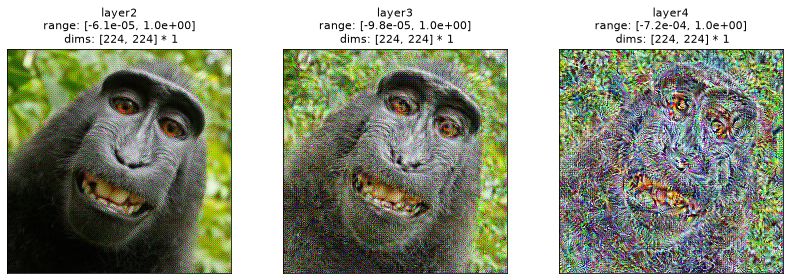

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, met, target_layer in zip(axes, metamers, layers):
    _ = po.plot.synthesis_imshow(met, ax=ax, title=target_layer, zoom=1)

In the above figure, we can see that our metamers look similar to those in {cite:alp}`Feather2023-model-metam`, figure 2e: the layer 2 metamer looks almost identical to the target image, the layer 3 metamer starts to add RGB noise, and the layer 4 has started to lose much of the structure in random RGB noise.

(feather-synthesis-success)=
## Synthesis success?

As indicated in the table above, the examples shown in the notebook only ran for 12,000 iterations of synthesis, whereas the metamers in {cite:alp}`Feather2023-model-metam` ran for twice that. Due to differences in the optimization procedure, it's not easy to directly interpret what this means. What we would like to know is whether synthesis has succeeded in these examples. The metamer loss (as stored in {attr}`plenoptic.Metamer.losses`) measures the difference between the target image and the model metamer, but is difficult to interpret. Is $10^{-6}$ small enough?

:::{seealso}

See [](good-enough) for another approach to this question.

:::

The authors of {cite:alp}`Feather2023-model-metam` define two criteria for synthesis success. Quoting from the Methods section, pdf page 19:

- First, "the activations for the model metamer had to be matched to those for the signal better than would be expected by chance". To do this, they compared the activity at the target layer for the model metamer and the target image using three metrics: Spearman $\rho$, Pearson $R^2$, and the signal-to-noise ratio. They then used these same metrics to generate a null distribution between 1,000,000 randomly chosen image pairs from the training dataset, and ensured that the model metamer fell outside this distribution.
- Second, "the models had to produce the same class label for the model metamer and the natural signal".

Without the null distributions of these three metrics, we cannot check the first criterion in this notebook. We note this criterion to point out that you should use a similar check when synthesizing your own model metamers for an experiment.

We can check the second one. Let's define a little helper function to return ResNet50's classification of an image. Fortunately for us, `torchvision` stores the image category labels along with the model weights:

In [6]:
imagenet_categories = np.asarray(weights.meta["categories"])
# Move deepnet to float64 since we know our images are all float64
deepnet.to(torch.float64).to(DEVICE)


def get_category(image):
    # Get probabilities of each image category
    image_cat = torch.nn.functional.softmax(deepnet(norm(image)), dim=1)
    # Convert to 1d numpy array, so we can use as index in
    # imagenet_categories above.
    image_cat = po.to_numpy(image_cat.squeeze())
    return imagenet_categories[image_cat.argmax()]


print(f"Target image category: {get_category(img)}")
for met, target_layer in zip(metamers, layers):
    met_cat = get_category(met.metamer)
    print(f"{target_layer} metamer category: {met_cat}")

Target image category: guenon
layer2 metamer category: guenon
layer3 metamer category: guenon
layer4 metamer category: guenon


We can see that all three of the above metamers are classified as the same category as the target image, a [guenon](https://en.wikipedia.org/wiki/Guenon). (Though guenon isn't the actual species of the monkey in question (a [Celebes crested macaque](https://en.wikipedia.org/wiki/Celebes_crested_macaque)), it's another Old World monkey, and a reasonable category for it.)

In this notebook we have demonstrated how to use plenoptic to synthesize image metamers for several ResNet50 layers, as done in {cite:alp}`Feather2023-model-metam`. That paper contains much more than these metamers (including audio metamers, the effect of deep net training, and many experiments with humans), so if you are interested in learning more, we encourage you to give it a read!